In [1]:
import pandas as pd
df=pd.read_csv('ai4i_predictive_maintenance.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
1,2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
2,3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
3,4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
4,5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M50739,M,301.7,311.1,1231,39.3,15,0,0,0,0,0,0
9996,9997,M39738,M,299.4,308.3,1558,33.5,248,0,0,0,0,0,0
9997,9998,H56921,H,302.4,313.0,1562,23.3,171,0,0,0,0,0,0
9998,9999,L71068,L,299.0,308.8,1373,45.5,238,0,0,0,0,0,0


In [4]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# remove 'UDI','Product ID','TWF','HDF',''PWF''OSF''RNF'
df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],axis=1,inplace=True)
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,L,297.9,307.1,1525,20.3,238,0
1,H,298.6,307.8,1384,32.3,249,0
2,M,305.0,314.1,1958,36.3,67,0
3,L,300.3,309.7,1009,46.8,248,1
4,L,300.7,311.6,1863,38.6,133,0
...,...,...,...,...,...,...,...
9995,M,301.7,311.1,1231,39.3,15,0
9996,M,299.4,308.3,1558,33.5,248,0
9997,H,302.4,313.0,1562,23.3,171,0
9998,L,299.0,308.8,1373,45.5,238,0


<Axes: ylabel='Air temperature [K]'>

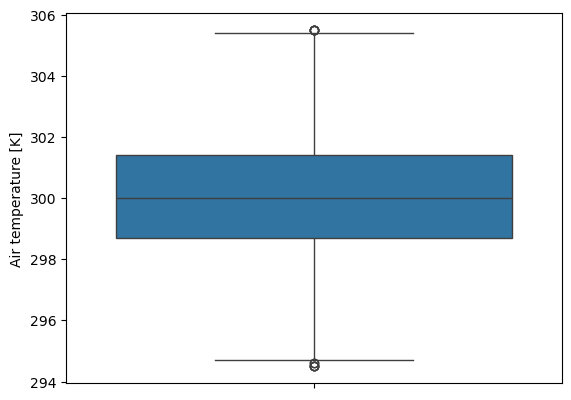

In [9]:
sns.boxplot(df['Air temperature [K]'])

In [8]:
# use iqr method to remove outliers
Q1=df['Air temperature [K]'].quantile(0.25)
Q3=df['Air temperature [K]'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Air temperature [K]']>=lower_bound) & (df['Air temperature [K]']<=upper_bound)]

<Axes: ylabel='Process temperature [K]'>

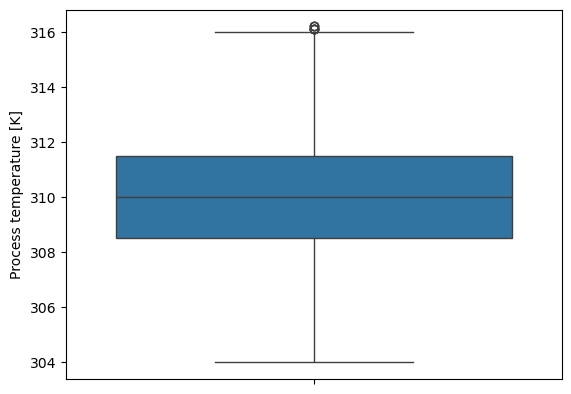

In [12]:
sns.boxplot(df['Process temperature [K]'])

In [11]:
# use iqr method to remove outliers from 'Process temperature [K]'
Q1=df['Process temperature [K]'].quantile(0.25)
Q3=df['Process temperature [K]'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Process temperature [K]']>=lower_bound) & (df['Process temperature [K]']<=upper_bound)]


<Axes: ylabel='Rotational speed [rpm]'>

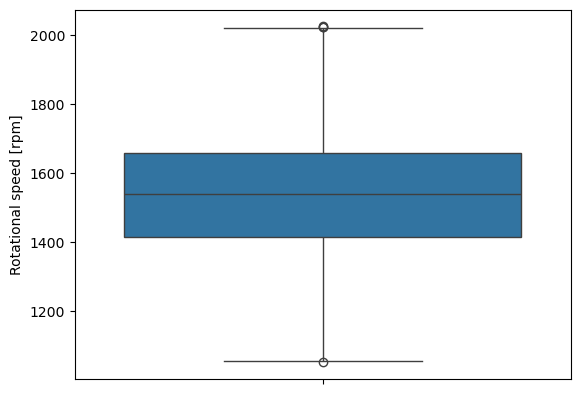

In [16]:
sns.boxplot(df['Rotational speed [rpm]'])

In [14]:
# use iqr method to remove outliers from 'Rotational speed [rpm]'
Q1=df['Rotational speed [rpm]'].quantile(0.25)
Q3=df['Rotational speed [rpm]'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Rotational speed [rpm]']>=lower_bound) & (df['Rotational speed [rpm]']<=upper_bound)]

<Axes: ylabel='Torque [Nm]'>

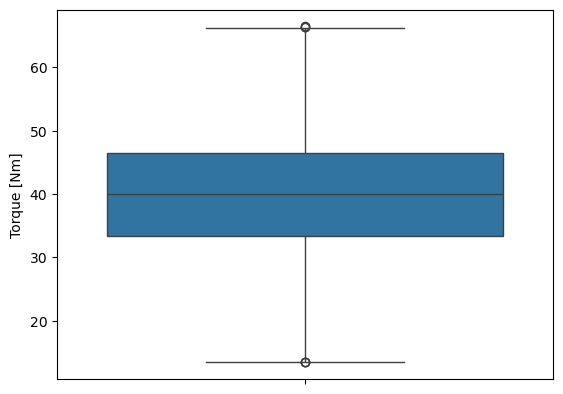

In [19]:
sns.boxplot(df['Torque [Nm]'])

In [18]:
# use iqr method to remove outliers from 'Torque [Nm]'
Q1=df['Torque [Nm]'].quantile(0.25)
Q3=df['Torque [Nm]'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Torque [Nm]']>=lower_bound) & (df['Torque [Nm]']<=upper_bound)]


In [20]:
df['Type'].value_counts()

Type
L    5976
M    2874
H     938
Name: count, dtype: int64

In [21]:
# in type convert 'L' to 0 and 'M' to 1 and 'H' to 2
df['Type']=df['Type'].map({'L':0,'M':1,'H':2})
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,0,297.9,307.1,1525,20.3,238,0
1,2,298.6,307.8,1384,32.3,249,0
2,1,305.0,314.1,1958,36.3,67,0
4,0,300.7,311.6,1863,38.6,133,0
5,0,297.6,309.4,1705,50.5,121,0
...,...,...,...,...,...,...,...
9995,1,301.7,311.1,1231,39.3,15,0
9996,1,299.4,308.3,1558,33.5,248,0
9997,2,302.4,313.0,1562,23.3,171,0
9998,0,299.0,308.8,1373,45.5,238,0


In [22]:
x=df.drop('Machine failure',axis=1)
y=df['Machine failure']

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
# use random forest classifier to train the model
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1958,))

In [26]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.9719101123595506
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1840
           1       0.88      0.62      0.73       118

    accuracy                           0.97      1958
   macro avg       0.93      0.81      0.86      1958
weighted avg       0.97      0.97      0.97      1958

Confusion Matrix:
[[1830   10]
 [  45   73]]
